# redoing the report with pandas

`visualize_data.py` works but it's stdlib-only, so every chart is hand-written svg string
concatenation. adding one more view means writing another `bar_chart()` by hand.

pandas and matplotlib are installed now so I'm redoing it. goal is the same: one self-contained
html file, no external assets. working it out here first, then I'll move it into a script.

In [1]:
import json, re, io
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

pd.__version__, matplotlib.__version__

('3.0.5', '3.11.2')

## getting it into frames

the json is nested three deep (contracts, paragraphs, qas) plus answers. I want flat tables.
three of them, since the natural grain is different: one row per contract, one per question,
one per annotated span.

In [2]:
def load(path):
    doc = json.loads(Path(path).read_text(encoding='utf-8'))
    docs, qas, spans = [], [], []
    for e in doc['data']:
        title = e['title']
        for pa in e['paragraphs']:
            ctx = pa['context']
            docs.append({'title': title, 'n_chars': len(ctx)})
            for qa in pa['qas']:
                cat = qa['id'].split('__')[-1]
                answers = qa.get('answers') or []
                found = bool(answers) and not qa.get('is_impossible', False)
                qas.append({'title': title, 'category': cat, 'found': found,
                            'n_spans': len(answers) if found else 0})
                for a in answers:
                    spans.append({'title': title, 'category': cat,
                                  'start': a['answer_start'], 'length': len(a['text']),
                                  'rel_pos': a['answer_start'] / len(ctx)})
    return pd.DataFrame(docs), pd.DataFrame(qas), pd.DataFrame(spans)

docs, qas, spans = load('data/CUADv1.json')
docs.shape, qas.shape, spans.shape

((510, 2), (20910, 4), (13823, 5))

In [3]:
qas.head()

,title,category,found,n_spans
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,True,1
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,True,5
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,True,1
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,True,2
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,True,1


good. 20910 questions, 13823 spans, 510 contracts. matches what I counted before.

## the category table

this is the thing the whole report hangs off. one row per clause type.

In [4]:
g = qas.groupby('category')
cats = pd.DataFrame({
    'asked': g.size(),
    'present': g.found.sum(),
    'spans': g.n_spans.sum(),
})
cats['rate'] = 100 * cats.present / cats.asked
cats['burst'] = cats.spans / cats.present.clip(lower=1)
cats.sort_values('rate', ascending=False).head()

,asked,present,spans,rate,burst
category,,,,,
Document Name,510,510,521,100.000000,1.021569
Parties,510,509,2554,99.803922,5.017682
Agreement Date,510,470,476,92.156863,1.012766
Governing Law,510,437,464,85.686275,1.061785
Expiration Date,510,413,467,80.980392,1.130751


that's the whole computation. compare to the stdlib version which needs a nested defaultdict
and a manual loop to get the same thing. this is why I'm redoing it.

In [5]:
sg = spans.groupby('category')
cats['median_span'] = sg.length.median()
cats['mean_rel_pos'] = sg.rel_pos.mean()
cats = cats.sort_values('rate', ascending=False)
cats.round(2).head(8)

,asked,present,spans,rate,burst,median_span,mean_rel_pos
category,,,,,,,
Document Name,510,510,521,100.00,1.02,25.0,0.08
Parties,510,509,2554,99.80,5.02,17.0,0.09
Agreement Date,510,470,476,92.16,1.01,16.0,0.11
Governing Law,510,437,464,85.69,1.06,178.5,0.78
Expiration Date,510,413,467,80.98,1.13,195.0,0.41
Effective Date,510,390,447,76.47,1.15,20.0,0.17
Anti-Assignment,510,374,654,73.33,1.75,218.5,0.71
Cap On Liability,510,275,672,53.92,2.44,306.0,0.62


## first chart

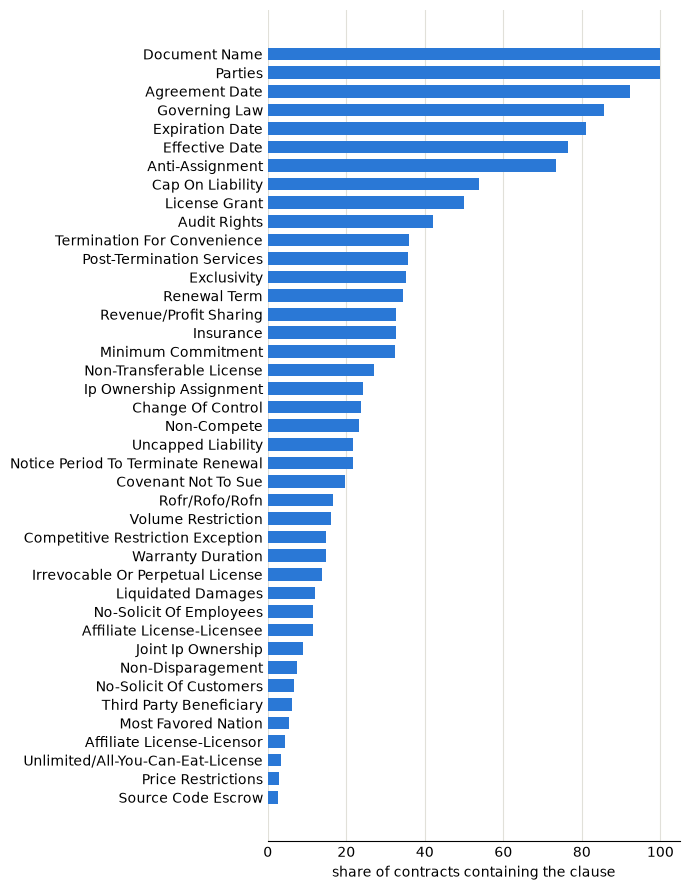

In [6]:
BLUE, MUTED, GRID = '#2a78d6', '#898781', '#e1e0d9'

d = cats.sort_values('rate')
fig, ax = plt.subplots(figsize=(7, 9))
ax.barh(d.index, d.rate, color=BLUE, height=.68)
ax.set_xlabel('share of contracts containing the clause')
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
ax.grid(axis='x', color=GRID)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()

fine. now let me point the same code at test.json and see if the shape holds.

In [7]:
tdocs, tqas, tspans = load('data/test.json')

tg = tqas.groupby('category')
tcats = pd.DataFrame({'asked': tg.size(), 'present': tg.found.sum(),
                      'spans': tg.n_spans.sum()})
tcats['median_span'] = tspans.groupby('category').length.median()
tcats.sort_values('present').head(4)

,asked,present,spans,median_span
category,,,,
Price Restrictions,102,0,0,NaN
Source Code Escrow,102,1,5,266.0
Unlimited/All-You-Can-Eat-License,102,3,6,463.0
Most Favored Nation,102,3,3,454.0


there's a NaN in median_span. which category.

In [8]:
tcats[tcats.median_span.isna()]

,asked,present,spans,median_span
category,,,,
Price Restrictions,102,0,0,NaN


price restrictions. present = 0, so there are no spans, so the median of an empty group is NaN.

which is correct behaviour, not a bug. but it means when I format this into an html table,
`int(nan)` is going to blow up. noting that for later.

In [9]:
# confirm it's genuinely absent rather than a name mismatch
'Price Restrictions' in set(tqas.category), tqas[tqas.category == 'Price Restrictions'].found.sum()

(True, np.int64(0))

In [10]:
# and it does exist in the full set
cats.loc['Price Restrictions', ['present', 'spans']]

present    15
spans      27
Name: Price Restrictions, dtype: int64

15 contracts have it, none of them are in test. so that category is unscoreable on this split.
already knew that but good to have the report handle it rather than crash.

## now the train file

same code, third file.

In [11]:
ndocs, nqas, nspans = load('data/train_separate_questions.json')

ncats = pd.DataFrame({'asked': nqas.groupby('category').size()})
ncats.sort_values('asked', ascending=False).head(8)

,asked
category,
Affiliate License-Licensee_0,408
Volume Restriction_0,408
Unlimited/All-You-Can-Eat-License_0,408
Uncapped Liability_0,408
Audit Rights_0,408
Anti-Assignment_0,408
Third Party Beneficiary_0,408
Cap On Liability_0,408


those aren't category names. `Parties_0`, `Parties_1`. something is wrong with my parsing.

In [12]:
nqas.category.nunique()

408

408, not 41. so `split('__')[-1]` is not giving me the category for this file.

In [13]:
raw = json.loads(Path('data/train_separate_questions.json').read_text(encoding='utf-8'))
[qa['id'] for qa in raw['data'][0]['paragraphs'][0]['qas'][:6]]

['LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name_0',
 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Parties_0',
 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Parties_1',
 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Parties_2',
 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Parties_3',
 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Parties_4']

every id has a trailing `_<n>`. this is the exploded format: a question with N gold spans gets
split into N separate single-answer questions. the squad training pipeline can only take one
start/end target per example, so they had to flatten it.

In [14]:
# every id, or only the multi-span ones?
ids = [qa['id'] for e in raw['data'] for pa in e['paragraphs'] for qa in pa['qas']]
sum(1 for i in ids if not re.search(r'_\d+$', i)), len(ids)

(0, 22450)

zero unsuffixed out of 22450. applied uniformly, even to single-span questions. so I can just
strip a trailing underscore-digits off every id and it'll be consistent across all three files.

In [15]:
def category_of_id(qid):
    return re.sub(r'_\d+$', '', qid.split('__')[-1])

# a few category names have slashes and hyphens in them, check those survive
for t in ['X__Parties_0', 'X__Parties_12', 'X__Rofr/Rofo/Rofn',
          'X__Unlimited/All-You-Can-Eat-License', 'X__Third Party Beneficiary']:
    print(f'{t:<45} -> {category_of_id(t)}')

X__Parties_0                                  -> Parties
X__Parties_12                                 -> Parties
X__Rofr/Rofo/Rofn                             -> Rofr/Rofo/Rofn
X__Unlimited/All-You-Can-Eat-License          -> Unlimited/All-You-Can-Eat-License
X__Third Party Beneficiary                    -> Third Party Beneficiary


In [16]:
len({category_of_id(i) for i in ids})

41

41. good.

In [17]:
def load2(path):
    doc = json.loads(Path(path).read_text(encoding='utf-8'))
    docs, qas, spans = [], [], []
    for e in doc['data']:
        title = e['title']
        for pa in e['paragraphs']:
            ctx = pa['context']
            docs.append({'title': title, 'n_chars': len(ctx)})
            for qa in pa['qas']:
                cat = category_of_id(qa['id'])
                answers = qa.get('answers') or []
                found = bool(answers) and not qa.get('is_impossible', False)
                qas.append({'title': title, 'category': cat, 'found': found,
                            'n_spans': len(answers) if found else 0})
                for a in answers:
                    spans.append({'title': title, 'category': cat,
                                  'start': a['answer_start'], 'length': len(a['text']),
                                  'rel_pos': a['answer_start'] / len(ctx)})
    return pd.DataFrame(docs), pd.DataFrame(qas), pd.DataFrame(spans)

ndocs, nqas, nspans = load2('data/train_separate_questions.json')
nqas.category.nunique()

41

41 categories now. but the exploded rows are going to bite somewhere else too.

In [18]:
ng = nqas.groupby('category')
ncats = pd.DataFrame({'asked': ng.size(), 'present': ng.found.sum()})
ncats.loc['Price Restrictions']

asked      420
present     27
Name: Price Restrictions, dtype: int64

27 contracts with a price restrictions clause? the full set only has 15, and I established
above that all 15 are in train. can't be 27.

In [19]:
nqas[(nqas.category == 'Price Restrictions') & nqas.found].title.nunique()

15

15. so `found.sum()` is counting rows, and each contract contributes several of them. `size()`
has the same problem so `asked` is inflated too, and the rate is wrong in both directions.

In [20]:
def cat_table(qas, spans):
    g = qas.groupby('category')
    c = pd.DataFrame({
        'asked': g.title.nunique(),                                      # contracts asked
        'present': qas[qas.found].groupby('category').title.nunique(),   # contracts where found
        'spans': g.n_spans.sum(),
    })
    c['present'] = c.present.fillna(0).astype(int)
    c['rate'] = 100 * c.present / c.asked
    c['burst'] = c.spans / c.present.clip(lower=1)
    sg = spans.groupby('category')
    c['median_span'] = sg.length.median()
    c['mean_rel_pos'] = sg.rel_pos.mean()
    return c.sort_values('rate', ascending=False)

cat_table(nqas, nspans).loc['Price Restrictions']

asked           408.000000
present          15.000000
spans            27.000000
rate              3.676471
burst             1.800000
median_span     282.000000
mean_rel_pos      0.406715
Name: Price Restrictions, dtype: float64

15. correct.

In [21]:
# and it should change nothing for the files that were never exploded
cats2 = cat_table(*load2('data/CUADv1.json')[1:])
(cats2.present == cats.present).all(), (cats2.rate.round(6) == cats.rate.round(6)).all()

(np.True_, np.True_)

unchanged for CUADv1, since there every category is exactly one row per contract. so the fix is
safe to apply everywhere.

two things to remember: `groupby.size()` is not a contract count, and test a parser against
every file it will see rather than just the first one.

## getting matplotlib figures into the html

want a single file with no external assets. png-as-base64 works but goes blurry and is big.
svg is text so it can be pasted straight into the body.

In [22]:
def svg(fig):
    buf = io.StringIO()
    fig.savefig(buf, format='svg', bbox_inches='tight', transparent=True)
    plt.close(fig)
    return buf.getvalue()

fig, ax = plt.subplots(figsize=(4, 2))
ax.barh(['a', 'b'], [3, 5], color=BLUE)
print(svg(fig)[:300])

<?xml version="1.0" encoding="utf-8" standalone="no"?>
<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"
  "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">
<svg xmlns:xlink="http://www.w3.org/1999/xlink" width="250.948437pt" height="142.28pt" viewBox="0 0 250.948437 142.28" xmlns="http://www.w3.org/


there's an xml prolog and a DOCTYPE on the front. fine standalone, but it can't sit inside an
html body. strip everything before the `<svg` tag.

In [23]:
def svg(fig):
    buf = io.StringIO()
    fig.savefig(buf, format='svg', bbox_inches='tight', transparent=True)
    plt.close(fig)
    return re.sub(r'^.*?(?=<svg)', '', buf.getvalue(), flags=re.S)

fig, ax = plt.subplots(figsize=(4, 2))
ax.barh(['a', 'b'], [3, 5], color=BLUE)
s = svg(fig)
print(s[:110])
print('...')
print(len(s), 'chars')

<svg xmlns:xlink="http://www.w3.org/1999/xlink" width="250.948437pt" height="142.28pt" viewBox="0 0 250.948437
...
9560 chars


`transparent=True` matters. otherwise matplotlib paints a white rectangle behind the plot and it
looks wrong the moment the page has any other background colour.

## assembling

In [24]:
def rarity_fig(cats):
    d = cats.sort_values('rate')
    fig, ax = plt.subplots(figsize=(7, .22 * len(d) + .6))
    ax.barh(d.index, d.rate, color=BLUE, height=.68)
    for y, (r, p) in enumerate(zip(d.rate, d.present)):
        ax.text(r + 1.2, y, f'{r:.1f}%  ({p})', va='center', fontsize=7, color=MUTED)
    ax.set_xlim(0, 120)
    ax.set_xlabel('share of contracts containing the clause')
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)
    ax.grid(axis='x', color=GRID)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return svg(fig)

len(rarity_fig(cats))

147018

In [25]:
# the nan guard I flagged earlier
def num(v, spec):
    return '&mdash;' if pd.isna(v) else format(v, spec)

num(float('nan'), ',.0f'), num(196.0, ',.0f')

('&mdash;', '196')

In [26]:
def table_html(c):
    head = ['Category', 'Present %', 'Spans when present', 'Contracts', 'Median span']
    rows = ['<table><thead><tr>' + ''.join(f'<th>{h}</th>' for h in head) + '</tr></thead><tbody>']
    for name, r in c.iterrows():
        rows.append(f'<tr><td>{name}</td><td>{r.rate:.1f}</td><td>{r.burst:.2f}</td>'
                    f'<td>{int(r.present)}</td><td>{num(r.median_span, ",.0f")}</td></tr>')
    return ''.join(rows) + '</tbody></table>'

print(table_html(cats)[:280])

<table><thead><tr><th>Category</th><th>Present %</th><th>Spans when present</th><th>Contracts</th><th>Median span</th></tr></thead><tbody><tr><td>Document Name</td><td>100.0</td><td>1.02</td><td>510</td><td>25</td></tr><tr><td>Parties</td><td>99.8</td><td>5.02</td><td>509</td><td


In [27]:
CSS = '''
body{margin:0;background:#f7f7f5;color:#0b0b0b;font:14px/1.6 system-ui,sans-serif}
.wrap{max-width:1000px;margin:0 auto;padding:40px 20px}
h1{font-size:26px;margin:0 0 6px} h2{font-size:17px;margin:40px 0 8px}
.panel{background:#fff;border:1px solid #e6e5e0;border-radius:8px;padding:16px;overflow-x:auto}
.panel svg{max-width:100%;height:auto;display:block}
table{border-collapse:collapse;font-size:12.5px;width:100%}
th,td{text-align:right;padding:6px 9px;border-bottom:1px solid #e6e5e0;font-variant-numeric:tabular-nums}
th:first-child,td:first-child{text-align:left}
th{color:#898781;font-size:10.5px;text-transform:uppercase;letter-spacing:.05em}
'''

html = f'''<!doctype html><html><head><meta charset="utf-8">
<title>CUAD report</title><style>{CSS}</style></head><body><div class="wrap">
<h1>CUAD dataset report</h1>
<p>{len(docs):,} contracts, {len(qas):,} questions, {int(qas.found.sum()):,} answered
({100 * qas.found.mean():.1f}%), {len(spans):,} spans.</p>
<h2>How often each clause appears</h2>
<div class="panel">{rarity_fig(cats)}</div>
<h2>Every category</h2>
<div class="panel">{table_html(cats)}</div>
</div></body></html>'''

Path('scratch_report.html').write_text(html, encoding='utf-8')
print(f'{len(html) / 1000:.0f} KB')

152 KB


In [28]:
from IPython.display import IFrame
IFrame('scratch_report.html', width='100%', height=500)

works. f-strings for the html are fine at this size. if it grows past a few sections I'd pull
the template out into its own string with placeholders, but not yet.

---

## moved into a script

cleaned this up into `report_pandas.py` with both fixes baked in (the regex on the category id,
and counting contracts rather than rows), plus the sections I didn't build here: burstiness
scatter, position heatmap, span lengths, test coverage.

```
python report_pandas.py
python report_pandas.py --file data/test.json --out test.html
```

### left to do
- [ ] dark mode. matplotlib bakes the text colour into the svg, so it'd need two renders or
      post-processing the svg to swap `fill` for `currentColor`
- [ ] the position heatmap is the slow bit, couple of seconds. fine for now
- [ ] should the report compare against train instead of test? would surface the exploded
      format, might just be confusing